In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from umap import UMAP  # pip install umap-learn
import re
from lux.lux import LUX
from collections import defaultdict
from sklearn import svm
from sklearn.metrics import f1_score



In [3]:
from sklearn.datasets import (
    load_iris,
    load_wine,
    load_breast_cancer,
    make_classification,
    make_moons,
    make_circles

)
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import fetch_openml
import pandas as pd


from typing import Tuple, Dict, Optional
import openml
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def load_dataset_oml(name: str) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Load an OpenML dataset by a friendly name and label-encode all categorical features.
    The target y is also label-encoded if it is non-numeric.

    Parameters
    ----------
    name : str
        One of the keys defined in `dataset_ids`.

    Returns
    -------
    X : pd.DataFrame
        Feature matrix with categorical columns label-encoded (dtype: int).
    y : np.ndarray
        Label-encoded target (if originally categorical) or numeric target as-is.

    Raises
    ------
    ValueError
        If `name` is unknown or mapped to None (e.g., UCI dataset without OpenML ID).
    """
    name = name.lower()

    # numerical-only OpenML datasets (with IDs)
    dataset_ids: Dict[str, Optional[int]] = {
        "openml_sonar": 40,
        "openml_credit_g": 31,        # 21 features, 1000 instances (borderline)
    }

    if name not in dataset_ids:
        raise ValueError(f"Unknown dataset: {name}")

    did = dataset_ids[name]
    if did is None:
        raise ValueError(
            f"Dataset '{name}' does not have an OpenML ID in this mapping. "
            "Please provide a valid OpenML ID or use an OpenML-available dataset key."
        )

    # Fetch dataset metadata and data
    data = openml.datasets.get_dataset(did)
    X, y, categorical_indicator, feature_names = data.get_data(
        dataset_format="dataframe",
        target=data.default_target_attribute
    )

    # --- Label-encode categorical feature columns ---
    # Fallback heuristic: also treat object/category dtypes as categorical, in case indicator is incomplete
    cat_cols_from_indicator = [fn for fn, is_cat in zip(feature_names, categorical_indicator) if is_cat]
    cat_cols_from_dtype = [c for c in X.columns if str(X[c].dtype) in ("object", "category")]
    cat_cols = list(dict.fromkeys(cat_cols_from_indicator + cat_cols_from_dtype))  # unique, stable order

    encoders_X: Dict[str, LabelEncoder] = {}
    for col in cat_cols:
        le = LabelEncoder()
        # Convert to string and fill NA with a sentinel to make encoding stable
        col_values = X[col].astype("string").fillna("<NA>").to_numpy()
        X[col] = le.fit_transform(col_values).astype(int)
        encoders_X[col] = le

    # --- Label-encode the target if needed ---
    y_encoded = y
    if isinstance(y, (pd.Series, pd.Categorical)) or hasattr(y, "dtype"):
        y_is_numeric = pd.api.types.is_numeric_dtype(y)
        if not y_is_numeric:
            le_y = LabelEncoder()
            # cast to string, handle NA similarly
            y_encoded = le_y.fit_transform(pd.Series(y, dtype="string").fillna("<NA>"))
        else:
            # Ensure numpy array
            y_encoded = np.asarray(y)
    else:
        # Non-pandas sequence: try numeric detection; if not numeric, encode as strings
        try:
            y_arr = np.asarray(y, dtype=float)
            y_encoded = y_arr
        except Exception:
            le_y = LabelEncoder()
            y_encoded = le_y.fit_transform(pd.Series(y, dtype="string").fillna("<NA>"))

    # If we need later need the encoders (for inverse_transform), you can return them as well:
    # return X, y_encoded, encoders_X, le_y if not y_is_numeric else None

    return X, y_encoded


def load_classification_dataset(
    name="iris",
    n_samples=100,
    n_features=20,
    n_classes=2,
    noise=0.1,
    random_state=42
):
    """
    Load a classification dataset as DataFrame (X) and array (y).

    Parameters:
    -----------
    name : str
        Dataset name. Options:
            - 'iris'
            - 'wine'
            - 'breast_cancer'
            - 'moons'
            - 'circles'
            - 'synthetic'
    n_samples : int
        Used for synthetic, two_moons, circles
    n_features : int
        Only used for 'synthetic'
    n_classes : int
        Only used for 'synthetic'
    noise : float
        Noise level for two_moons and circles
    random_state : int
        Random seed for reproducibility

    Returns:
    --------
    X_df : pd.DataFrame
        Features
    y : np.ndarray
        Target labels
    """

    if name == "iris":
        data = load_iris()
        X_df = pd.DataFrame(
            data.data,
            columns=[f.replace("(cm)", "").replace(" ", "_") for f in data.feature_names]
        )
        y = data.target

    elif name == "wine":
        data = load_wine()
        X_df = pd.DataFrame(data.data, columns=data.feature_names)
        y = data.target

    elif name == "breast_cancer":
        data = load_breast_cancer()
        X_df = pd.DataFrame(data.data, columns=data.feature_names)
        y = data.target


    elif name == "synthetic":
        X, y = make_classification(
            n_samples=n_samples,
            n_features=n_features,
            n_informative=int(n_features * 0.6),
            n_redundant=int(n_features * 0.2),
            n_repeated=0,
            n_classes=n_classes,
            random_state=random_state
        )
        X_df = pd.DataFrame(X, columns=[f"feat_{i}" for i in range(X.shape[1])])
    elif name == "pima":
        data = fetch_openml(
            name="diabetes",
            version=1,
            as_frame=True
        )
        X_df = data.data
        y = data.target.map({'tested_negative': 0, 'tested_positive': 1}).to_numpy()
    elif 'openml' in name:
        
        X_df,y = load_dataset_oml(name)
        la = LabelEncoder()
        y = la.fit_transform(y)
    elif name == "coalmine":
        coal=pd.read_csv("https://gitlab.geist.re/pml/x_benchmark-with-selected-datasets/-/raw/main/CDS1/clustering-results-coal-mine-knac.zip")
        coal.columns = ['timestamp', 'cluster',
         'LCD_AverageThree_phaseCurrent_discrete',
               'RCD_AverageThree_phaseCurrent_discrete', 'LHD_EngineCurrent_discrete',
               'RHD_EngineCurrent_discrete', 'LP_AverageThree_phaseCurrent_discrete',
               'SM_ShearerSpeed_discrete',
               'LHD_LeftHaulageDrive_tractor_Temperature_gearbox_discrete',
               'LA_LeftArmTemperature_discrete', 'SM_DailyRouteOfTheShearer_discrete',
               'SM_TotalRoute_discrete', 'SM_ShearerLocation_discrete',
               'SM_ShearerMoveInLeft', 'SM_ShearerMoveInRight',
               'RCD_AverageThree_phaseCurrent', 'LCD_AverageThree_phaseCurrent',
               'LP_AverageThree_phaseCurrent', 'LHD_EngineCurrent',
               'RHD_EngineCurrent', 'SM_ShearerSpeed',
               'LHD_LeftHaulageDrive_tractor_Temperature(gearbox)',
               'LA_LeftArmTemperature', 'SM_DailyRouteOfTheShearer', 'SM_TotalRoute',
               'SM_ShearerLocation', 'expert']
        coal.sort_values(by='timestamp', inplace=True)
        coal = coal.iloc[:100000]
        features= [f for f in coal.columns if f not in ['expert','timestamp','cluster']]
        target = 'cluster'
        
        X_df=coal[features]
        y = coal[target]
    else:
        raise ValueError(f"Unknown dataset name: {name}")

    return X_df, y



In [4]:
rules_total_exp = []

# Step 4: Parser & comparison functions (same as before)
def parse_lux_rule(lux_justify_output):
    if not lux_justify_output or not isinstance(lux_justify_output, list) or len(lux_justify_output) == 0:
        return None
    block = lux_justify_output[0]
    if not isinstance(block, list) or len(block) == 0:
        return None
    item = block[0]
    
    rule_dict = {
        'conditions': [],
        'prediction': item.get('prediction'),
        'confidence': float(item.get('confidence', 0.0))
    }
    
    raw_rules = item.get('rule', {})
    for feat_expr, cond_list in raw_rules.items():
        for cond_str in cond_list:
            match_simple = re.match(r'([<>]=?)\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', cond_str.strip())
            match_oblique = re.match(r'([<>]=?)\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*\*\s*(\w+)\s*([+-])\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', cond_str.strip())
            
            if match_simple:
                op, thresh = match_simple.groups()
                rule_dict['conditions'].append((feat_expr, op, float(thresh)))
            elif match_oblique:
                op, coef, feat, sign, const = match_oblique.groups()
                coef = float(coef)
                const_val = float(const) if sign == '+' else -float(const)
                rule_dict['conditions'].append((feat_expr, op, f"{coef} * {feat} + {const_val}"))
            else:
                rule_dict['conditions'].append((feat_expr, None, cond_str))
    
    return rule_dict

def rule_to_query(rule):
    """
    Convert a parsed rule's conditions to a pandas.query string.
    Assumes rule['conditions'] is list of (feat, op, thresh) or raw strings.
    Handles simple ops; for oblique, assume string is eval-able as is.
    """
    cond_strs = []
    for cond in rule['conditions']:
        if isinstance(cond, tuple):
            feat, op, thresh = cond
            # Clean op to pandas syntax
            if op == '>=':
                op_q = '>='
            elif op == '>':
                op_q = '>'
            elif op == '<=':
                op_q = '<='
            elif op == '<':
                op_q = '<'
            else:
                continue  # skip unknown
            cond_strs.append(f"`{feat}` {op_q} {thresh}")
        elif isinstance(cond, str):
            # Raw string: assume like '>= -1.268 * petal_length_ + 7.799'
            # Replace to pandas-safe (e.g., add backticks if needed, but assume feats are valid col names)
            cond_strs.append(cond)  # May need cleaning for oblique
    return ' & '.join(cond_strs) if cond_strs else 'True'  # Default true if no conds

def get_covered_indices(df, rule):
    """
    Get set of row indices covered by the rule.
    """
    query_str = rule_to_query(rule)
    if not query_str or query_str == 'True':
        return set(df.index)  # Covers all if no conditions
    try:
        covered_df = df.query(query_str)
        return set(covered_df.index)
    except Exception as e:
        print(f"Query error for rule: {query_str} - {e}")
        return set()  # Empty if error

def rules_disagree(rule_a, rule_b, df, overlap_threshold=0.5, alpha=0.3, beta=0.2):
    if not rule_a or not rule_b:
        return 0.0
    
    # Empirical coverage
    indices_a = get_covered_indices(df, rule_a)
    indices_b = get_covered_indices(df, rule_b)
    
    if not indices_a or not indices_b:
        return 0.0
    
    intersection = indices_a & indices_b
    union = indices_a | indices_b
    spatial_overlap = len(intersection) / len(union) if len(union) > 0 else 0.0
    
    if spatial_overlap < overlap_threshold:
        return 0.0
    
    # Optional: still include feat overlap bonus if needed
    feats_a = {c[0] for c in rule_a['conditions'] if c[0] is not None}
    feats_b = {c[0] for c in rule_b['conditions'] if c[0] is not None}
    shared = feats_a & feats_b
    union_feats = feats_a | feats_b
    feat_overlap = len(shared) / len(union_feats) if union_feats else 0.0
    
    conf_bonus = min(rule_a['confidence'], rule_b['confidence']) if rule_a['prediction'] == rule_b['prediction'] else 0.0

    # weighting is in fact not that important, it is more for visualizaiotn, as cc-edu is a sum
    score = spatial_overlap * (0.5 + alpha * feat_overlap + beta * conf_bonus)
    return min(max(score, 0.0), 1.0)


def is_contradictory(rule_a, rule_b, df, min_overlap=0.1, knn_indices=None, instance_idx=None):
    if rule_a['prediction'] == rule_b['prediction']:
        return False

    indices_a = get_covered_indices(df, rule_a)
    indices_b = get_covered_indices(df, rule_b)

    if knn_indices is not None and instance_idx is not None:
        neighbors = set(knn_indices[instance_idx][1:])
        indices_a &= neighbors
        indices_b &= neighbors

    if not indices_a or not indices_b:
        return False

    intersection = indices_a & indices_b
    union = indices_a | indices_b
    spatial_overlap = len(intersection) / len(union) if union else 0.0

    return spatial_overlap >= min_overlap

def satisfies_rule_row(rule_dict, row):
    """
    Check if a single row satisfies a rule.
    rule_dict example:
      {'feature1': (low, high), 'feature2': ('<=', 0.4)}
    """
    for feat, cond in rule_dict.items():
        val = row[feat]

        if isinstance(cond, tuple) and len(cond) == 2:
            lo, hi = cond
            if not (lo <= val <= hi):
                return False

        elif isinstance(cond, tuple) and len(cond) == 2 and isinstance(cond[0], str):
            op, thr = cond
            if op == "<=" and not val <= thr:
                return False
            if op == ">=" and not val >= thr:
                return False

        else:
            raise ValueError(f"Unknown condition format: {cond}")

    return True


def predict_with_lux_rules(X, rules_total_exp, default_class=None):
    """
    Predict labels for X using LUX rules in the nested format:
    rules_total_exp = [[[{'rule': {...}, 'prediction': '1', 'confidence': 0.6}]], ...]

    Returns:
        y_pred: np.array of predicted labels
        coverage: np.array of fraction of rules covering each instance
    """
    # Flatten rules inside
    flat_rules = []
    for item in rules_total_exp:
        # item is a list of lists
        for sublist in item:
            for rule_dict in sublist:
                flat_rules.append({
                    "rule_dict": rule_dict.get("rule", {}),
                    "prediction": rule_dict.get("prediction"),
                    "confidence": float(rule_dict.get("confidence", 1.0))
                })
    
    n_samples = X.shape[0]
    y_pred = np.empty(n_samples, dtype=object)
    coverage = np.zeros(n_samples)  # how many rules fired
    
    def satisfies_rule_row(rule_dict, row):
        """Check if a single row satisfies a rule (empty rule covers all)."""
        if not rule_dict:
            return True
        for feat, cond_list in rule_dict.items():
            for cond_str in cond_list:
                cond_str = cond_str.strip()
                if cond_str.startswith(('>=', '>', '<=', '<')):
                    op = cond_str[:2] if cond_str[:2] in ['>=', '<='] else cond_str[0]
                    try:
                        thresh = float(cond_str[len(op):])
                        val = row[feat]
                        if op == '>=' and not val >= thresh:
                            return False
                        elif op == '>' and not val > thresh:
                            return False
                        elif op == '<=' and not val <= thresh:
                            return False
                        elif op == '<' and not val < thresh:
                            return False
                    except:
                        return False
                else:
                    return False
        return True

    for idx in range(n_samples):
        row = X.iloc[idx]
        votes = defaultdict(float)
        votes_counts = defaultdict(float)
        rules_fired = 0
        
        
        for rule in flat_rules:
            if satisfies_rule_row(rule["rule_dict"], row):
                pred = rule["prediction"]
                votes[pred] += rule.get("confidence", 1.0)
                votes_counts[pred] +=1
                rules_fired += 1
        
        coverage[idx] = rules_fired / len(flat_rules) if flat_rules else 0.0
        
        if votes:
            for pred in votes.keys():
                votes[pred] = votes[pred]/votes_counts[pred] if votes_counts[pred]> 0 else 0
            # Choose the class with highest weighted votes
            y_pred[idx] = max(votes.items(), key=lambda x: x[1])[0]
        else:
            # Fallback
            y_pred[idx] = default_class if default_class is not None else None

    return np.array(y_pred), coverage

def extract_rules_lux(
    X_test_df_scaled,
    X_train_scaled_df,
    y_train,
    mw,
    lux_locality=0.02,
):
    rules = []
    rules_parsed=[]

    lux = LUX(
        predict_proba=mw.predict_proba,
        neighborhood_size=lux_locality,
        max_depth=2,
        oversampling_strategy='importance',
        node_size_limit=2,
        grow_confidence_threshold=0
    )

    for i in range(len(X_test_df_scaled)):
        instance_df = X_test_df_scaled.iloc[[i]]
        instance_np = instance_df.to_numpy()

        lux.fit(
            X_train_scaled_df,
            y_train,
            instance_to_explain=instance_np,
            tree_with_shap=False,
            oblique=False
        )
        justify = lux.justify(instance_np, to_dict=True)
        rule = parse_lux_rule(justify)
        rules_parsed.append(rule)
        rules.append(justify)

    return rules, rules_parsed, lux


from sklearn.neighbors import NearestNeighbors
import numpy as np

# ---------------------------
# 3. CC-EDU computation (local)
# ---------------------------
def compute_cc_edu(
    rules,
    X_test_df_scaled,
    k=20,
    overlap_threshold=0.1
):
    """
    Compute CC-EDU scores using k-NN neighborhoods.
    """
    X_np = X_test_df_scaled.to_numpy()
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_np)
    _, knn_indices = nbrs.kneighbors(X_np)

    edu_scores = np.zeros(len(rules))

    for i, rule_i in enumerate(rules):
        if rule_i is None:
            continue

        disagreement = 0.0
        valid_count = 0

        for j in knn_indices[i][1:]:  # skip self
            rule_j = rules[j]
            if rule_j is None:
                continue

            if is_contradictory(rule_i, rule_j, X_test_df_scaled,
                                min_overlap=overlap_threshold,
                                knn_indices=knn_indices,
                                instance_idx=i):
                disagreement += rules_disagree(rule_i, rule_j, X_test_df_scaled,
                                                 overlap_threshold=overlap_threshold)

            valid_count += 1

        if valid_count > 0:
            edu_scores[i] = disagreement / valid_count

    return edu_scores,knn_indices

    
# Step 5: CC-EDU computation
def compute_cc_edu_lux(X_test_df_scaled, mw, k=20, lux_locallity=0.02, overlap_threshold=0.1):
    rules,rules_parsed,lux = extract_rules_lux(
        X_test_df_scaled,
        X_train_scaled_df,
        y_train,
        mw,
        lux_locality=lux_locallity
        )
    
    # Step 2: compute CC-EDU (method-agnostic)
    edu_scores,knn_indices = compute_cc_edu(
        rules_parsed,
        X_test_df_scaled,
        k=k,
        overlap_threshold=overlap_threshold
    )
    
    return edu_scores, lux, rules,knn_indices

def directional_disagreement(rule_i, rule_j, df, knn_indices=None, instance_idx=None):
    Ci = get_covered_indices(df, rule_i)
    Cj = get_covered_indices(df, rule_j)

    if knn_indices is not None and instance_idx is not None:
        neighbors = set(knn_indices[instance_idx][1:])  # skip self
        Ci &= neighbors
        Cj &= neighbors

    if not Ci or not Cj:
        return 0.0, set()
    Dij = Ci & Cj
    strength = len(Dij) / len(Ci) if len(Ci) > 0 else 0.0
    return strength, Dij



import numpy as np

def rule_bounds(rule):
    """
    Extract per-feature bounds from rule conditions.
    Returns: {feat: {'lb': value or -inf, 'ub': value or +inf}}
    """
    bounds = {}

    for feat, op, thr in rule['conditions']:
        if feat not in bounds:
            bounds[feat] = {'lb': -np.inf, 'ub': np.inf}

        if op == '>=':
            bounds[feat]['lb'] = max(bounds[feat]['lb'], thr)
        elif op == '>':
            bounds[feat]['lb'] = max(bounds[feat]['lb'], thr)
        elif op == '<=':
            bounds[feat]['ub'] = min(bounds[feat]['ub'], thr)
        elif op == '<':
            bounds[feat]['ub'] = min(bounds[feat]['ub'], thr)

    return bounds



def learn_restriction_from_opponent(rule_i, rule_j, df):
    """
    Derive restriction conditions for rule_i by inverting rule_j's bounds.
    Only adds conditions where rule_i is not already tighter.
    """
    bounds_j = rule_bounds(rule_j)
    bounds_i = rule_bounds(rule_i)
    
    new_conditions = []
    
    for feat, bj in bounds_j.items():
        bi = bounds_i.get(feat, {'lb': -np.inf, 'ub': np.inf})
        
        # rule_j claims feat >= lb_j → push rule_i to feat < lb_j
        if bj['lb'] > -np.inf and bi['lb'] < bj['lb']:
            new_conditions.append((feat, '<', bj['lb']))
        
        # rule_j claims feat <= ub_j → push rule_i to feat > ub_j
        if bj['ub'] < np.inf and bi['ub'] > bj['ub']:
            new_conditions.append((feat, '>', bj['ub']))
    
    return new_conditions


from sklearn.tree import DecisionTreeClassifier

def learn_restriction_decision_tree(rule_i, disagree_idx, df, max_depth=1):
    """
    Learn a restriction from the disagreement region by fitting a small decision tree.
    Returns a list of new (feat, op, threshold) conditions.
    """
    covered_idx = get_covered_indices(df, rule_i)
    if not covered_idx or not disagree_idx:
        return None

    agree_idx = covered_idx - disagree_idx
    if not agree_idx:
        return None  # nothing to learn

    # Construct training data
    X = df.loc[list(covered_idx)].copy()
    y = np.array([1 if i in agree_idx else 0 for i in covered_idx])

    # Fit small decision tree
    clf = DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(X, y)

    # Convert tree splits into axis-aligned conditions
    conditions = []

    tree = clf.tree_
    features = X.columns

    # Only handle splits at root for simplicity (can extend for max_depth>1)
    def traverse(node_id=0):
        if tree.feature[node_id] == -2:  # leaf
            return

        feat = features[tree.feature[node_id]]
        thr = tree.threshold[node_id]

        # Determine which side is "agree"
        left_agree = tree.value[tree.children_left[node_id]][0][1]
        right_agree = tree.value[tree.children_right[node_id]][0][1]

        if left_agree > right_agree:
            # left ≤ threshold → agree
            conditions.append((feat, '<=', thr))
        else:
            # right > threshold → agree
            conditions.append((feat, '>=', thr))

        # traverse children
        traverse(tree.children_left[node_id])
        traverse(tree.children_right[node_id])

    traverse(0)
    return conditions if conditions else None




def restrict_rule(rule, restriction_cond):
    """
    Add a restriction condition to a rule (AND).
    """
    if restriction_cond is None:
        return rule

    new_rule = rule.copy()
    new_rule['conditions'] = list(rule['conditions']) + [restriction_cond]

    
    return new_rule


def restrict_rule_safe(rule_i, cond, instance_idx, df):
    """
    Only apply restriction if the explained instance still falls inside the rule.
    """
    candidate = restrict_rule(rule_i, cond)
    covered = get_covered_indices(df, candidate)
    if instance_idx in covered:
        return candidate
    return rule_i  # revert if instance got cut out



def conditions_to_lux_rule(conditions):
    """
    Convert [('feat', '>=', thr), ...] to:
    {'feat': ['>=thr'], ...}
    """
    lux_rule = {}

    for feat, op, thr in conditions:
        if feat not in lux_rule:
            lux_rule[feat] = []
        lux_rule[feat].append(f"{op}{thr}")

    return lux_rule

def normalized_rule_to_lux(rule):
    """
    Convert internal rule format back to LUX-compatible dict.
    """
    return {
        'rule': conditions_to_lux_rule(rule['conditions']),
        'prediction': rule['prediction'],
        'confidence': rule['confidence'],
    }


def restrict_rules(
    rules_total_exp,
    X_df,
    overlap_threshold=0.1,
    restriction_threshold=0.1,
    k=20,
    knn_indices=None
):
    """
    Apply directional rule restriction with k-NN locality.
    Returns restricted rules and the knn_indices used.
    """
    # Compute k-NN once
    if knn_indices is None:
        X_np = X_df.to_numpy()
        nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_np)
        _, knn_indices = nbrs.kneighbors(X_np)

    restricted_rules = []
    contradictions =[]

    for i in range(len(rules_total_exp)):
        rule_i_list = rules_total_exp[i]
        if not rule_i_list:
            restricted_rules.append([[]])
            continue

        rule_i = parse_lux_rule(rule_i_list)
        if rule_i is None:
            restricted_rules.append([[]])
            continue

        for j in range(len(rules_total_exp)):
            if i == j:
                continue

            rule_j_list = rules_total_exp[j]
            if not rule_j_list:
                continue

            rule_j = parse_lux_rule(rule_j_list)
            if rule_j is None:
                continue

            # 1. Must be a genuine contradiction (local)
            if not is_contradictory(rule_i, rule_j, X_df,
                                    min_overlap=overlap_threshold,
                                    knn_indices=knn_indices,
                                    instance_idx=i):
                continue

            # 2. Only restrict rule_i if it is the overgeneral one
            Ci = get_covered_indices(X_df, rule_i)
            Cj = get_covered_indices(X_df, rule_j)

            rule_i_is_overgeneral = (
                len(Ci) > len(Cj) and
                rule_i['confidence'] <= rule_j['confidence']
            )

            if not rule_i_is_overgeneral:
                continue

            # 2. Disagreement region must be meaningful
            strength, Dij = directional_disagreement(rule_i, rule_j, X_df,
                                                     knn_indices=knn_indices)
            if strength < restriction_threshold:
                continue

            contradictions.append([rule_i,rule_j])
            # 3. Learn restriction from disagreement region
            new_conds = learn_restriction_decision_tree(rule_i, Dij, X_df, max_depth=1)

            # 4. Apply each condition safely
            if new_conds:
                for cond in new_conds:
                    rule_i = restrict_rule_safe(rule_i, cond, i, X_df)

        lux_rule = normalized_rule_to_lux(rule_i)
        restricted_rules.append([[lux_rule]])

    return restricted_rules, knn_indices, contradictions #return contradicted rules to show


In [5]:
import os
import json
import numpy as np
from datetime import datetime

def save_grid_results(base_dir: str,
                      dnsname: str,
                      dsname: str,
                      edu_avg_grid: np.ndarray,
                      f1_all_grid: np.ndarray,
                      edu_avg_grid_r: np.ndarray,
                      f1_all_grid_r: np.ndarray,
                      extra_meta: dict | None = None) -> str:
    """
    Save grid-search result arrays and metadata under:
        {base_dir}/{dnsname}/{dsname}.npz and {dsname}.json

    Returns the path to the saved .npz file.
    """
    save_dir = os.path.join(base_dir, dnsname)
    os.makedirs(save_dir, exist_ok=True)

    npz_path = os.path.join(save_dir, f"{dsname}.npz")
    np.savez_compressed(
        npz_path,
        edu_avg_grid=edu_avg_grid,
        f1_all_grid=f1_all_grid,
        edu_avg_grid_r=edu_avg_grid_r,
        f1_all_grid_r=f1_all_grid_r,
    )

    meta = {
        "dnsname": dnsname,
        "dsname": dsname,
        "shape": {
            "edu_avg_grid": list(edu_avg_grid.shape),
            "f1_all_grid": list(f1_all_grid.shape),
            "edu_avg_grid_r": list(edu_avg_grid_r.shape),
            "f1_all_grid_r": list(f1_all_grid_r.shape),
        },
        "saved_at": datetime.now().isoformat(timespec="seconds")
    }
    if extra_meta:
        meta.update(extra_meta)

    json_path = os.path.join(save_dir, f"{dsname}.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    return npz_path

In [6]:
def plot_rule_parcoords(
    rules_parsed,
    edu_scores,
    X_test_scaled_df,
    class_colors=None
):
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.colors import Normalize
    import numpy as np

    # ─────────────────────────────────────────────────────────────
    # Clean white scientific style
    # ─────────────────────────────────────────────────────────────
    plt.rcParams.update({
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "font.size": 9
    })

    features = list(X_test_scaled_df.columns)
    n_feats = len(features)

    feat_min = X_test_scaled_df.min()
    feat_max = X_test_scaled_df.max()

    def scale_val(feat, val):
        lo, hi = feat_min[feat], feat_max[feat]
        if hi == lo:
            return 0.5
        return (val - lo) / (hi - lo)

    def unscale_val(feat, val_scaled):
        lo, hi = feat_min[feat], feat_max[feat]
        return lo + val_scaled * (hi - lo)

    # ─────────────────────────────────────────────────────────────
    # Class colors
    # ─────────────────────────────────────────────────────────────
    if class_colors is None:
        palette = plt.cm.tab10.colors
        all_preds = [r['prediction'] for r in rules_parsed if r is not None]
        unique_preds = sorted(set(all_preds))
        class_colors = {p: palette[i % 10] for i, p in enumerate(unique_preds)}

    norm_edu = Normalize(vmin=0, vmax=max(edu_scores.max(), 0.01))

    # ─────────────────────────────────────────────────────────────
    # Figure
    # ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(
        figsize=(max(12, n_feats * 2.2), 7),
        facecolor="white"
    )
    ax.set_facecolor("white")

    tick_positions = [0.0, 0.25, 0.5, 0.75, 1.0]

    # ─────────────────────────────────────────────────────────────
    # Vertical axes
    # ─────────────────────────────────────────────────────────────
    for fi, feat in enumerate(features):
        ax.axvline(fi, color='#cccccc', linewidth=1.0, zorder=1)

        ax.text(
            fi, -0.08, feat,
            ha='center', va='top',
            fontsize=9,
            rotation=25,
            transform=ax.get_xaxis_transform()
        )

        for tick_pos in tick_positions:
            real_val = unscale_val(feat, tick_pos)

            ax.plot(
                [fi - 0.04, fi + 0.04],
                [tick_pos, tick_pos],
                color='#bbbbbb',
                linewidth=0.8,
                zorder=5
            )

            ax.text(
                fi - 0.06, tick_pos,
                f"{real_val:.2f}",
                ha='right',
                va='center',
                fontsize=6.5,
                zorder=5
            )

    ax.set_xlim(-0.5, n_feats - 0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([])
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # ─────────────────────────────────────────────────────────────
    # Draw rules
    # ─────────────────────────────────────────────────────────────
    for i, rule in enumerate(rules_parsed):

        if rule is None:
            continue

        edu = edu_scores[i]
        alpha = norm_edu(edu)

        pred = rule['prediction']
        color = class_colors.get(pred, 'black')

        bounds = rule_bounds(rule)

        xs, y_lows, y_highs, is_constrained = [], [], [], []

        for feat in features:
            b = bounds.get(feat, {})
            lb = b.get('lb', -np.inf)
            ub = b.get('ub', np.inf)

            feat_constrained = not (np.isinf(lb) and np.isinf(ub))
            is_constrained.append(feat_constrained)

            lb_plot = scale_val(feat, max(lb, feat_min[feat])) if not np.isinf(lb) else 0.0
            ub_plot = scale_val(feat, min(ub, feat_max[feat])) if not np.isinf(ub) else 1.0

            xs.append(len(xs))
            y_lows.append(lb_plot)
            y_highs.append(ub_plot)

        xs = np.array(xs)
        y_lows = np.array(y_lows)
        y_highs = np.array(y_highs)
        y_mids = (y_lows + y_highs) / 2

        # ── Segment drawing ─────────────────────────────
        for fi in range(len(xs) - 1):

            left_constrained = is_constrained[fi]
            right_constrained = is_constrained[fi + 1]

            poly_x = [xs[fi], xs[fi+1], xs[fi+1], xs[fi]]
            poly_y = [y_lows[fi], y_lows[fi+1], y_highs[fi+1], y_highs[fi]]

            if left_constrained and right_constrained:

                ax.fill(
                    poly_x, poly_y,
                    color=color,
                    alpha=alpha * 0.45,
                    zorder=2
                )

            elif left_constrained or right_constrained:

                ax.fill(
                    poly_x, poly_y,
                    color=color,
                    alpha=alpha * 0.15,
                    zorder=2,
                    hatch='////',
                    linewidth=0
                )

                constrained_fi = fi if left_constrained else fi + 1

                ax.plot(
                    [xs[constrained_fi], xs[constrained_fi]],
                    [y_lows[constrained_fi], y_highs[constrained_fi]],
                    color=color,
                    alpha=alpha,
                    linewidth=3.5,
                    solid_capstyle='round',
                    zorder=4
                )

            else:
                ax.fill(
                    poly_x, poly_y,
                    color='#dddddd',
                    alpha=0.15,
                    zorder=1
                )

        # ── Constrained axis markers ─────────────────────
        for fi in range(len(xs)):
            if is_constrained[fi]:
                ax.plot(
                    [xs[fi], xs[fi]],
                    [y_lows[fi], y_highs[fi]],
                    color=color,
                    alpha=alpha,
                    linewidth=4.0,
                    solid_capstyle='round',
                    zorder=4
                )

        # ── Centerline ───────────────────────────────────
        constrained_xs = xs[np.array(is_constrained)]
        constrained_mids = y_mids[np.array(is_constrained)]

        if len(constrained_xs) > 0:
            ax.plot(
                constrained_xs,
                constrained_mids,
                color=color,
                alpha=alpha,
                linewidth=1.2 + 1.5 * norm_edu(edu),
                zorder=5,
                marker='o',
                markersize=3
            )

    # ─────────────────────────────────────────────────────────────
    # Legend
    # ─────────────────────────────────────────────────────────────
    patches = [
        mpatches.Patch(color=c, label=f'Class {p}')
        for p, c in class_colors.items()
    ]

    constrained_note = mpatches.Patch(
        facecolor='gray',
        alpha=0.4,
        label='Solid band = both axes constrained'
    )

    partial_note = mpatches.Patch(
        facecolor='gray',
        alpha=0.15,
        hatch='////',
        label='Hatched = one axis unconstrained'
    )

    edu_note = mpatches.Patch(
        facecolor='gray',
        alpha=0.3,
        label='Opacity + line weight ~ CC-EDU'
    )

    ax.legend(
        handles=patches + [constrained_note, partial_note, edu_note],
        loc='upper right',
        fontsize=8,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc'
    )

    ax.set_title(
        'Rule-Region Parallel Coordinates — Feature Bounds per Rule\n'
        'Bold bar = constrained axis  |  Hatched = extends to boundary  |  '
        'Opacity = CC-EDU',
        fontsize=12,
        pad=18
    )

    plt.tight_layout()

    plt.savefig(
        f"parcoords_rules_{dsname}.pdf",
        format="pdf",
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()


# Evaluation

In [7]:
# LUX = MockLUX   # uncomment for testing without real LUX
# ────────────────────────────────────────────────

# Step 1: Load data – keep as DataFrame
dsname="iris" #iris, pima, wine, breast_cancer, coalmine,    "openml_eucalyptus" "openml_credit_g":

X_df,y=load_classification_dataset(name=dsname, n_samples=100, n_features=20, n_classes=2)
X_train_df, X_test_df, y_train_real, y_test_real = train_test_split(
    X_df, y, test_size=0.3, random_state=42
)

# Step 2: Scale — but keep DataFrame structure
scaler = StandardScaler()
X_train_scaled_df = pd.DataFrame(
    scaler.fit_transform(X_train_df),
    columns=X_train_df.columns,
    index=X_train_df.index
)

X_test_scaled_df = pd.DataFrame(
    scaler.transform(X_test_df),
    columns=X_test_df.columns,
    index=X_test_df.index
)

# Also create NumPy versions only where strictly needed (e.g. UMAP, NearestNeighbors)
X_test_scaled_np = X_test_scaled_df.to_numpy()

# Step 3: Train model (can use scaled DataFrame or NumPy – RandomForest accepts both)
mw = RandomForestClassifier(n_estimators=100, random_state=42)#svm.SVC(probability=True)#RandomForestClassifier(n_estimators=100, random_state=42)
mw.fit(X_train_scaled_df, y_train_real)
print(f"Model Accuracy: {mw.score(X_test_scaled_df, y_test_real):.2f}")

y_test = mw.predict(X_test_scaled_df)
y_train = mw.predict(X_train_scaled_df)

Model Accuracy: 1.00


## Contour

In [8]:
X_test_scaled_df.shape

(45, 4)

In [9]:
import numpy as np
from sklearn.metrics import f1_score
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import os

locality=min(100,X_test_scaled_df.shape[0]-1)

# how much of Ri coverage is contradictory
RESTRICTION_THRESHOLD = 0.01 

# Threshold for visualizing disagreement edges
OVERLAP_THRESHOLD = 0.01

avg = "micro"

# Parameter grids
locality_values = np.arange(
    5, 
    min(100, X_test_scaled_df.shape[0] - 1) + 1,
    5
)
lux_locality_values = np.linspace(0.01, 0.5, 15)

# Result containers
f1_all_grid = np.zeros((len(lux_locality_values), len(locality_values)))
edu_avg_grid = np.zeros((len(lux_locality_values), len(locality_values)))

f1_all_grid_r = np.zeros((len(lux_locality_values), len(locality_values)))
edu_avg_grid_r = np.zeros((len(lux_locality_values), len(locality_values)))




def worker(task):
    """
    One grid-point computation.
    """
    i, j, lux_locality, locality = task

    # --- CC-EDU ---
    print(f'Starting {task}')
    edu_scores, lux,rules_total_exp,knn_indices = compute_cc_edu_lux(
        X_test_scaled_df,
        mw,
        k=locality,
        lux_locallity=lux_locality,
        overlap_threshold=OVERLAP_THRESHOLD
    )
    edu_avg = np.mean(edu_scores)

    # --- Prediction ---
    y_pred, covered = predict_with_lux_rules(
        X_test_scaled_df,
        rules_total_exp
    )

    y_pred = np.array([int(p) if p is not None else -1 for p in y_pred])
    mask = (covered > 0) & (y_pred != None)

    f1 = f1_score(
        y_test,
        y_pred,
        average=avg
    )

    restricted_rules,_,_ = restrict_rules(rules_total_exp, X_test_scaled_df, OVERLAP_THRESHOLD, RESTRICTION_THRESHOLD, knn_indices=knn_indices)

    y_pred_r, covered = predict_with_lux_rules(
        X_test_scaled_df,
        restricted_rules
    )

    y_pred_r = np.array([int(p) if p is not None else -1 for p in y_pred_r])
    mask = (covered > 0) & (y_pred_r != None)

    f1_r = f1_score(
        y_test,
        y_pred_r,
        average=avg
    )
    edu_scores_r,_ = compute_cc_edu(
        [parse_lux_rule(r) for r in restricted_rules],
        X_test_scaled_df,
        k=locality,
        overlap_threshold=OVERLAP_THRESHOLD
    )
    
    edu_avg_r = np.mean(edu_scores_r)
    
    print(f'Completing {task} with edu {edu_avg}')

    return i, j, edu_avg, f1, f1_r, edu_avg_r


# Build task list
tasks = [
    (i, j, lux_locality, locality)
    for i, lux_locality in enumerate(lux_locality_values)
    for j, locality in enumerate(locality_values)
]

# Use ~170 cores (or slightly less to keep OS alive)
n_workers = min(40, os.cpu_count())

print(f"Running with {n_workers} workers, total tasks: {len(tasks)}")

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    futures = [executor.submit(worker, task) for task in tasks]

    for future in tqdm(as_completed(futures), total=len(futures), desc="Grid search"):
        i, j, edu_avg, f1,f1_r, edu_avg_r = future.result()
        edu_avg_grid[i, j] = edu_avg
        f1_all_grid[i, j] = f1
        edu_avg_grid_r[i, j] = edu_avg_r
        f1_all_grid_r[i, j] = f1_r




# ... run your grid search to fill these arrays ...
# edu_avg_grid, f1_all_grid, edu_avg_grid_r, f1_all_grid_r = ...
dnsname = "grid-data"   # folder name grouping a set of datasets
base_dir = "./results"  # local or Google Drive

saved_path = save_grid_results(
    base_dir=base_dir,
    dnsname=dnsname,
    dsname=dsname,
    edu_avg_grid=edu_avg_grid,
    f1_all_grid=f1_all_grid,
    edu_avg_grid_r=edu_avg_grid_r,
    f1_all_grid_r=f1_all_grid_r,
)
print(f"Saved: {saved_path}")



Running with 40 workers, total tasks: 120


Grid search:   0%|          | 0/120 [00:00<?, ?it/s]

Starting (0, 0, 0.01, 5)
Starting (0, 1, 0.01, 10)Starting (0, 2, 0.01, 15)Starting (0, 3, 0.01, 20)

Starting (0, 4, 0.01, 25)Starting (0, 5, 0.01, 30)
Starting (0, 6, 0.01, 35)Starting (1, 0, 0.045, 5)Starting (0, 7, 0.01, 40)Starting (1, 4, 0.045, 25)Starting (1, 2, 0.045, 15)Starting (1, 5, 0.045, 30)


Starting (1, 1, 0.045, 10)
Starting (1, 3, 0.045, 20)Starting (1, 6, 0.045, 35)Starting (2, 1, 0.07999999999999999, 10)Starting (2, 4, 0.07999999999999999, 25)
Starting (2, 3, 0.07999999999999999, 20)Starting (2, 2, 0.07999999999999999, 15)Starting (2, 6, 0.07999999999999999, 35)

Starting (1, 7, 0.045, 40)
Starting (3, 1, 0.11499999999999998, 10)Starting (3, 0, 0.11499999999999998, 5)Starting (2, 0, 0.07999999999999999, 5)Starting (3, 3, 0.11499999999999998, 20)Starting (3, 2, 0.11499999999999998, 15)Starting (2, 5, 0.07999999999999999, 30)

Starting (2, 7, 0.07999999999999999, 40)Starting (3, 7, 0.11499999999999998, 40)
Starting (4, 0, 0.15, 5)
Starting (3, 4, 0.11499999999999998,

Grid search:   1%|          | 1/120 [00:03<07:11,  3.63s/it]


Completing (0, 0, 0.01, 5) with edu 0.03916049382716049
Starting (5, 1, 0.185, 10)
Completing (1, 1, 0.045, 10) with edu 0.059629629629629616
Starting (5, 2, 0.185, 15)

...

Completing (13, 6, 0.46499999999999997, 35) with edu 0.0
Completing (14, 6, 0.5, 35) with edu 0.0


Grid search:  98%|█████████▊| 118/120 [00:19<00:00,  3.57it/s]

Completing (13, 7, 0.46499999999999997, 40) with edu 0.0
Completing (14, 7, 0.5, 40) with edu 0.0


Grid search: 100%|██████████| 120/120 [00:20<00:00,  5.74it/s]

Saved: ./results/grid-data/iris.npz


In [10]:
L, Lux = np.meshgrid(locality_values, lux_locality_values)

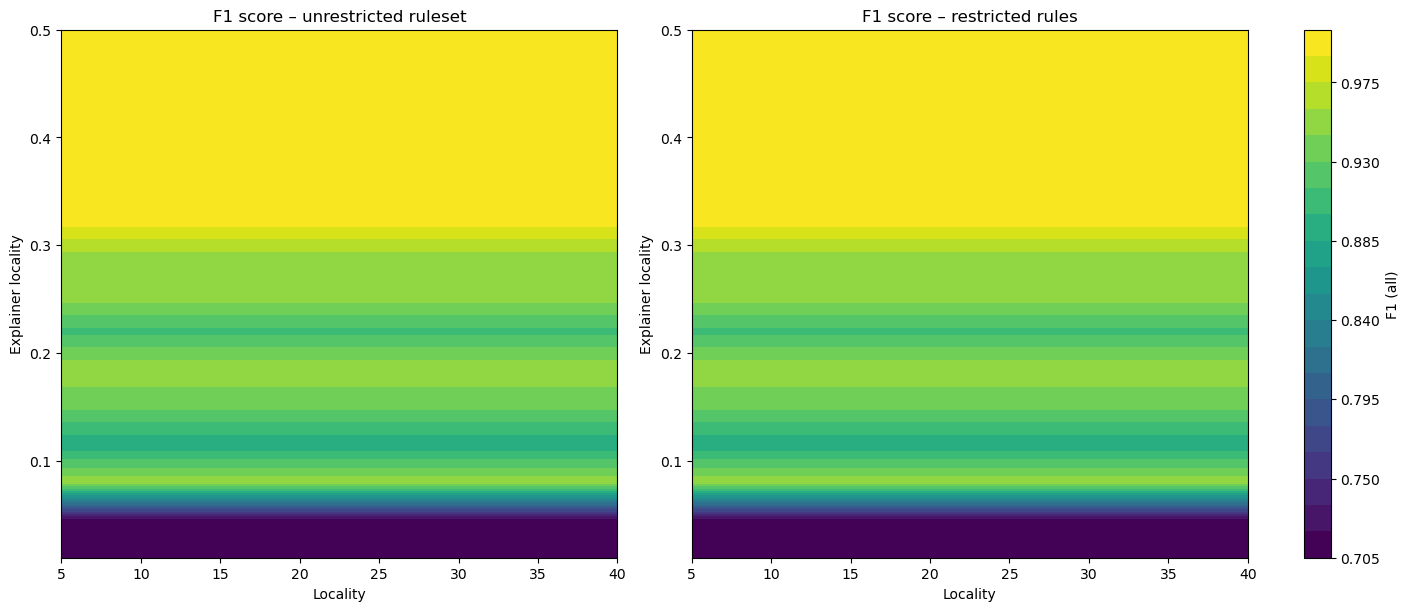

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Compute shared color range
vmin = min(f1_all_grid.min(), f1_all_grid_r.min())
vmax = max(f1_all_grid.max(), f1_all_grid_r.max())

# Use constrained_layout to manage spacing more robustly
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# --- First subplot ---
cont1 = axes[0].contourf(L, Lux, f1_all_grid, levels=20, vmin=vmin, vmax=vmax)
axes[0].set_title("F1 score – unrestricted ruleset")
axes[0].set_xlabel("Locality")
axes[0].set_ylabel("Explainer locality")

# --- Second subplot ---
cont2 = axes[1].contourf(L, Lux, f1_all_grid_r, levels=20, vmin=vmin, vmax=vmax)
axes[1].set_title("F1 score – restricted rules")
axes[1].set_xlabel("Locality")
axes[1].set_ylabel("Explainer locality")

# --- One shared colorbar outside (right) ---
# 'ax=axes' attaches it to both; 'pad' controls distance; 'fraction' the size of the bar
cbar = fig.colorbar(cont1, ax=axes, location='right', fraction=0.046, pad=0.04)
cbar.set_label("F1 (all)")

# Save combined figure
plt.savefig(
    f"f1_score_locality_vs_lux_{dsname}_combined_same_scale.pdf",
    format="pdf", bbox_inches="tight"
)
plt.show()

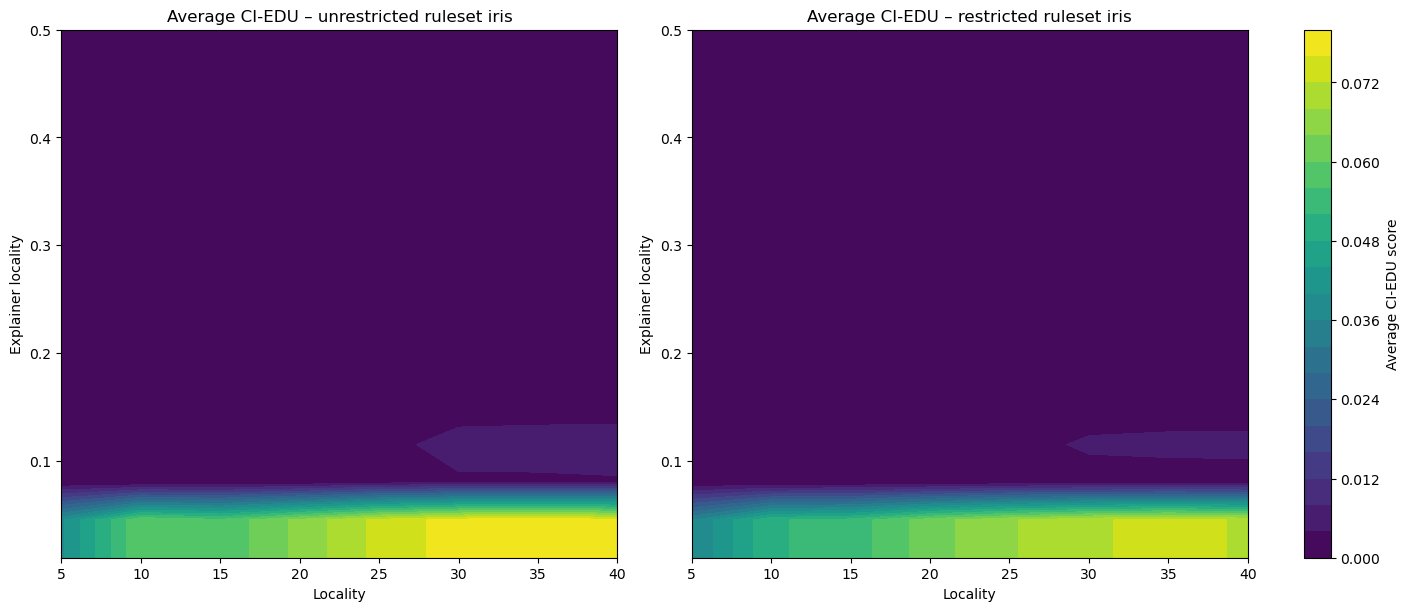

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Shared color range across both grids
vmin = min(edu_avg_grid.min(), edu_avg_grid_r.min())
vmax = max(edu_avg_grid.max(), edu_avg_grid_r.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# --- First subplot ---
cont1 = axes[0].contourf(
    L, Lux, edu_avg_grid,
    levels=20, vmin=vmin, vmax=vmax
)
axes[0].set_title(f"Average CC-EDU – unrestricted ruleset {dsname}")
axes[0].set_xlabel("Locality")
axes[0].set_ylabel("Explainer locality")

# --- Second subplot ---
cont2 = axes[1].contourf(
    L, Lux, edu_avg_grid_r,
    levels=20, vmin=vmin, vmax=vmax
)
axes[1].set_title(f"Average CC-EDU – restricted ruleset {dsname}")
axes[1].set_xlabel("Locality")
axes[1].set_ylabel("Explainer locality")

# --- Shared colorbar on the right, outside ---
cbar = fig.colorbar(
    cont1, ax=axes,
    location="right",
    fraction=0.046,
    pad=0.04
)
cbar.set_label("Average CC-EDU score")


# Save figure
plt.savefig(
    f"cc_edu_score_locality_vs_lux_{dsname}_combined_same_scale.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [13]:
SxzX

NameError: name 'SxzX' is not defined

## Histograms

In [ ]:
%%time
locality=min(100,X_test_scaled_df.shape[0]-1)
lux_locallity=0.055

# how much of Ri coverage is contradictory
RESTRICTION_THRESHOLD = 0.01 

# Threshold for visualizing disagreement edges
OVERLAP_THRESHOLD = 0.05



# Threshold for visualizing disagreement edges

edu_scores,lux, rules_total_exp,_= compute_cc_edu_lux(X_test_scaled_df, mw,k=locality, lux_locallity=lux_locallity, overlap_threshold=OVERLAP_THRESHOLD)
print("CC-EDU Scores (sample):", edu_scores[:5])

y_pred, covered = predict_with_lux_rules(X_test_scaled_df, rules_total_exp)
avg='micro'

mask = (covered > 0) & (y_pred != None)
y_pred = np.array([int(p) for p in y_pred])

results = {
    "f1_all": f1_score(y_test, y_pred, average=avg),
    "f1_covered": f1_score(y_test[mask], y_pred[mask], average=avg),
    "average_coverage_per_rule": covered.mean(),
    "n_test": len(y_test),
    "n_covered": mask.sum()
}

results

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ────────────────────────────────────────────────────────────────
#   Prepare combined dataframe with EDU scores
# ────────────────────────────────────────────────────────────────

df_vis = X_test_scaled_df.copy()
df_vis['cc_edu'] = edu_scores

# ────────────────────────────────────────────────────────────────
#   Plot one histogram per feature with EDU-colored bars
# ────────────────────────────────────────────────────────────────

n_features = len(X_test_scaled_df.columns)
n_cols = min(3, n_features)                # e.g. 3 plots per row
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), 
                         sharey=False, constrained_layout=True)

axes = axes.flat if n_features > 1 else [axes]

for i, feature in enumerate(X_test_scaled_df.columns):
    ax = axes[i]
    
    # ── Create histogram with bins, also get bin edges and counts ──
    counts, bin_edges, patches = ax.hist(
        df_vis[feature], 
        bins=25, 
        density=False, 
        alpha=0.9, 
        color='lightgray',  # fallback
        edgecolor='black',
        linewidth=0.6
    )
    
    # ── Compute average EDU per bin ──
    bin_indices = np.digitize(df_vis[feature], bin_edges) - 1   # 0-based
    bin_indices = np.clip(bin_indices, 0, len(bin_edges)-2)     # avoid overflow
    
    avg_edu_per_bin = np.zeros(len(counts))
    for b in range(len(counts)):
        mask = (bin_indices == b)
        if mask.sum() > 0:
            avg_edu_per_bin[b] = df_vis.loc[mask, 'cc_edu'].mean()
        else:
            avg_edu_per_bin[b] = 0
    
    # ── Color patches according to average EDU ──
    norm = plt.Normalize(0, max(edu_scores.max(), 0.01))   # avoid div-by-zero
    cmap = plt.cm.RdBu_r                                   # red=high disagreement
    
    for patch, avg_edu in zip(patches, avg_edu_per_bin):
        color = cmap(norm(avg_edu))
        patch.set_facecolor(color)
    
    # ── Add colorbar (only once, on last plot or separate) ──
    if i == n_features - 1:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Average CC-EDU in bin\n(higher = more disagreement)')
    
    ax.set_title(feature, fontsize=11)
    ax.set_xlabel("Scaled value")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3, axis='y')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions colored by Average Explanatory Disagreement (CC-EDU)", 
             fontsize=14, y=1.02)

plt.savefig("feature_histograms_by_edu.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ──────────────────────────────────────────────
# Compute high-disagreement edges
# ──────────────────────────────────────────────


# Precompute contradictions between test instances
high_disagree_edges = []  # list of (i,j) tuples
high_disagree_rules = []

for i in range(len(rules_total_exp)):
    rule_i_list = rules_total_exp[i]
    if not rule_i_list: 
        continue
    rule_i = parse_lux_rule(rule_i_list)  # Take first rule as representative
    for j in range(i+1, len(rules_total_exp)):
        rule_j_list = rules_total_exp[j]
        if not rule_j_list:
            continue
        rule_j = parse_lux_rule(rule_j_list) 
        
        
        if rule_i and rule_j:
            if is_contradictory(rule_i, rule_j, X_test_scaled_df, min_overlap=OVERLAP_THRESHOLD):
                high_disagree_edges.append((i, j))
                high_disagree_rules.append((rule_i,rule_j))



In [ ]:
high_disagree_rules

In [ ]:
len(high_disagree_rules)

In [ ]:
from itertools import combinations

def satisfies_rule(rule_dict, feat_x, feat_y, x_val, y_val):
    satisfied = True
    for feat, cond_list in rule_dict.items():
        if feat != feat_x and feat != feat_y:
            continue  # Ignore other features
        
        for cond_str in cond_list:
            cond_str = cond_str.strip()
            if cond_str.startswith(('>=', '>', '<=', '<')):
                op = cond_str[:2] if cond_str[:2] in ['>=', '<='] else cond_str[0]
                thresh_str = cond_str[len(op):].strip()
                try:
                    thresh = float(thresh_str)
                    feat_val = x_val if feat == feat_x else y_val
                    if op == '>=':
                        satisfied &= (feat_val >= thresh)
                    elif op == '>':
                        satisfied &= (feat_val > thresh)
                    elif op == '<=':
                        satisfied &= (feat_val <= thresh)
                    elif op == '<':
                        satisfied &= (feat_val < thresh)
                except ValueError:
                    satisfied = False
                    break
            else:
                satisfied = False
                break
    return satisfied

# ──────────────────────────────────────────────
# Modified plotting with edges
# ──────────────────────────────────────────────

df_plot = X_test_scaled_df.copy()
df_plot['cc_edu'] = edu_scores
df_plot['true_class'] = y_test
df_plot['index'] = df_plot.index  # For annotations

# Top disagreed instances (top 5 by EDU)
top_disagreed = df_plot.nlargest(5, 'cc_edu').index.tolist()

feature_pairs = list(combinations(X_test_scaled_df.columns, 2))
n_pairs = len(feature_pairs)
n_cols = min(3, n_pairs)
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6 * n_rows),
                         constrained_layout=True)

axes = axes.flatten()
norm_edu = plt.Normalize(vmin=0, vmax=max(edu_scores.max(), 0.01))
cmap_edu = 'RdBu_r'
class_colors = {'0': 'blue', '1': 'green', '2': 'red'}  # Adjust for your classes


all_rules = []
for i, rule_group in enumerate(rules_total_exp):
    for sublist in rule_group:
        for r in sublist:
            all_rules.append({
                'rule_dict': r['rule'],
                'prediction': r['prediction'],
                'confidence': float(r['confidence']),
                'edu': edu_scores[i],
                'instance_idx': i
            })

for idx, (feat_x, feat_y) in enumerate(feature_pairs):
    ax = axes[idx]
    
    # Scatter points colored by CC-EDU
    sc_points = ax.scatter(
        df_plot[feat_x], df_plot[feat_y],
        c=df_plot['cc_edu'], cmap=cmap_edu, norm=norm_edu,
        alpha=0.85, s=60, edgecolor='gray', linewidth=0.4, zorder=4
    )
    
    # Draw edges for high-disagreement pairs
    for i, j in high_disagree_edges:
        x_vals = [df_plot.iloc[i][feat_x], df_plot.iloc[j][feat_x]]
        y_vals = [df_plot.iloc[i][feat_y], df_plot.iloc[j][feat_y]]
        ax.plot(x_vals, y_vals, color='black', alpha=0.4, linewidth=1.0, zorder=2)

    
    # ── Meshgrid, coverage, conflict regions as before ─────────
    x_min, x_max = df_plot[feat_x].min() - 0.5, df_plot[feat_x].max() + 0.5
    y_min, y_max = df_plot[feat_y].min() - 0.5, df_plot[feat_y].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150),
                         np.linspace(y_min, y_max, 150))
    
    coverage = {pred: np.zeros_like(xx) for pred in class_colors.keys()}
    for rule_info in all_rules:
        rule_dict = rule_info['rule_dict']
        pred = rule_info['prediction']
        conf = rule_info['confidence']
        involved_feats = set(rule_dict.keys())
        if not {feat_x, feat_y} & involved_feats:
            continue
        mask = np.vectorize(lambda x, y: satisfies_rule(rule_dict, feat_x, feat_y, x, y))(xx, yy)
        coverage[pred] += mask.astype(float) * conf
    
    conflict = np.zeros_like(xx)
    for pred in coverage:
        conflict += (coverage[pred] > 0).astype(int)
    
    for pred, cov in coverage.items():
        single_mask = (cov > 0) & (conflict == 1)
        if np.any(single_mask):
            ax.contourf(xx, yy, single_mask, levels=[0.5, 1], colors=class_colors[pred],
                        alpha=0.35, zorder=1)
    
    mixed_mask = (conflict >= 2)
    if np.any(mixed_mask):
        ax.contourf(xx, yy, mixed_mask, levels=[0.5, 1], colors='black',
                    alpha=0.3, hatches=['//'], zorder=2)
    
    for pred, cov in coverage.items():
        ax.contour(xx, yy, cov > 0, levels=[0.5], colors=class_colors[pred],
                   linewidths=1.0, alpha=0.6, linestyles='dashed', zorder=3)
    
    # Annotate top disagreed instances
    for inst_idx in top_disagreed:
        if inst_idx not in df_plot.index:
            continue
    
        pos = df_plot.index.get_loc(inst_idx)  # label → position
    
        x_pos = df_plot.iloc[pos][feat_x]
        y_pos = df_plot.iloc[pos][feat_y]
        edu_val = df_plot.iloc[pos]['cc_edu']
    
        ax.annotate(
            f"Inst {inst_idx}: {edu_val:.2f}",
            (x_pos, y_pos),
            xytext=(10, 10),
            textcoords='offset points',
            fontsize=9,
            color='black',
            weight='bold',
            arrowprops=dict(arrowstyle='->', color='black', alpha=0.7),
            zorder=5
        )
        
    ax.set_title(f"{feat_x} vs {feat_y}", fontsize=12)
    ax.set_xlabel(f"{feat_x} (scaled)")
    ax.set_ylabel(f"{feat_y} (scaled)")
    ax.grid(True, alpha=0.3)
    
    if idx == n_pairs - 1:
        cbar = fig.colorbar(sc_points, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('CC-EDU\n(high = disagreement)')

# Hide unused
for ax in axes[n_pairs:]:
    ax.set_visible(False)

fig.suptitle("Feature Pair Scatters with Rule Regions, Conflicts & Disagreement Edges",
             fontsize=15, y=1.02)

plt.savefig("scatter_with_disagreement_edges.png", dpi=180, bbox_inches='tight')
plt.show()


In [ ]:
rules_total_exp[0]

In [ ]:
from matplotlib.colors import Normalize
rules_parsed = [parse_lux_rule(r) for r in rules_total_exp if True or r[0][0]['rule']!={}]
# Instance view — interactive HTML
# plot_instance_parcoords(X_test_scaled_df, edu_scores, y_test, rules_parsed, k=5, edu_threshold=0.1)


In [ ]:
# Rule-region view — static, bands show feature coverage
plot_rule_parcoords(rules_parsed, edu_scores, X_test_scaled_df)

# Conflict-pair overlay — explicitly shows which rules fight each other


In [ ]:
# plot_conflict_pairs_overlay(rules_parsed, edu_scor@#es, X_test_scaled_df, top_n_conflicts=20)

## Solve disagreaments

In [ ]:
%%time
locality=19#min(100,X_test_scaled_df.shape[0]-1)
lux_locallity=0.03

# how much of Ri coverage is contradictory
RESTRICTION_THRESHOLD = 0.01  

OVERLAP_THRESHOLD = 0.01



# Threshold for visualizing disagreement edges

edu_scores,lux, rules_total_exp,knn_indices= compute_cc_edu_lux(X_test_scaled_df, mw,k=locality, lux_locallity=lux_locallity, overlap_threshold=OVERLAP_THRESHOLD)
print("CC-EDU Scores (sample):", edu_scores[:5])

y_pred, covered = predict_with_lux_rules(X_test_scaled_df, rules_total_exp)
avg='micro'

mask = (covered > 0) & (y_pred != None)
y_pred = np.array([int(p) for p in y_pred])

results = {
    "f1_all": f1_score(y_test, y_pred, average=avg),
    "f1_covered": f1_score(y_test[mask], y_pred[mask], average=avg),
    "average_coverage_per_rule": covered.mean(),
    "n_test": len(y_test),
    "n_covered": mask.sum()
}

results

In [ ]:
restricted_rules,_,contradictions = restrict_rules(rules_total_exp, X_test_scaled_df, OVERLAP_THRESHOLD,RESTRICTION_THRESHOLD,knn_indices=knn_indices)#RESTRICTION_THRESHOLD)

In [ ]:
#rules_total_exp=[r for r in rules_total_exp if r[0][0]['rule']!={}]
#restricted_rules=[r for r in restricted_rules if r[0][0]['rule']!={}]

In [ ]:
y_pred, covered = predict_with_lux_rules(X_test_scaled_df, rules_total_exp)
y_pred_restricted, covered_restricted = predict_with_lux_rules(X_test_scaled_df, restricted_rules)

In [ ]:
y_pred

In [ ]:
y_pred_restricted

In [ ]:
y_test

In [ ]:
edu_scores,_ = compute_cc_edu(
        [parse_lux_rule(r) for r in rules_total_exp],
        X_test_scaled_df,
        k=locality,
        overlap_threshold=OVERLAP_THRESHOLD
    )
edu_scores.mean()

In [ ]:
edu_scores_r,_ = compute_cc_edu(
        [parse_lux_rule(r) for r in restricted_rules],
        X_test_scaled_df,
        k=locality,
        overlap_threshold=OVERLAP_THRESHOLD
    )
edu_scores_r.mean()

In [ ]:
avg='micro'

mask = (covered > 0) & (y_pred != None)
y_pred = np.array([int(p) for p in y_pred])

results = {
    "f1_all": f1_score(y_test, y_pred, average=avg),
    "f1_covered": f1_score(y_test[mask], y_pred[mask], average=avg),
    "average_coverage_per_rule": covered.mean(),
    "n_test": len(y_test),
    "n_covered": mask.sum()
}


In [ ]:
avg='micro'

mask = (covered_restricted > 0) & (y_pred_restricted != None)
y_pred_restricted = np.array([int(p) if p is not None else -1 for p in y_pred_restricted])


results_restricted = {
    "f1_all": f1_score(y_test, y_pred_restricted, average=avg),
    "f1_covered": f1_score(y_test[mask], y_pred_restricted[mask], average=avg),
    "average_coverage_per_rule": covered.mean(),
    "n_test": len(y_test),
    "n_covered": mask.sum()
}


In [ ]:
pd.DataFrame([results, results_restricted])

In [ ]:
restricted_rules[1]

In [ ]:
# Rule-region view — static, bands show feature coverage
restricted_rules_parsed = [parse_lux_rule(r) for r in [restricted_rules[1]] if True or r[0][0]['rule']!={}]
plot_rule_parcoords(restricted_rules_parsed, edu_scores_r, X_test_scaled_df)

# Conflict-pair overlay — explicitly shows which rules fight each other

In [ ]:
for r, rr in zip(rules_total_exp, restricted_rules):
    print(f'RULE {r}\nRESTRICTED:{rr}\n========================================')